# Assignment 1: Visual and Graphical Display
**Course:** Data Science for Managerial Decisions  
**Objective:** Exploratory Data Analysis & Visualization  
**Data Source:** `Excel_HandsON.xlsx`

---

## 1. Environment Setup & Aesthetic Styling
We configure global plotting defaults using `matplotlib` and `seaborn` to ensure all charts maintain a clean, consistent typography and custom grid layout.

In [6]:
import os
import urllib.request

DATA_PATH = "Excel_HandsON.xlsx"

# Automatically fetch dataset if running inside Google Colab environment
if not os.path.exists(DATA_PATH):
    print("Cloud execution environment detected. Fetching Excel dataset...")
    raw_url = "https://raw.githubusercontent.com/ayaanjauhar/excel_python_project/main/Excel_HandsON.xlsx"
    urllib.request.urlretrieve(raw_url, DATA_PATH)
    print("✅ Dataset successfully pulled into environment!")
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Configure global aesthetics for custom visual styling
plt.style.use(
    "seaborn-v0_8-whitegrid"
    if "seaborn-v0_8-whitegrid" in plt.style.available
    else "default"
)
plt.rcParams.update(
    {
        "font.sans-serif": "DejaVu Sans",
        "axes.edgecolor": "#d0d0d0",
        "axes.linewidth": 0.8,
        "grid.color": "#f0f0f0",
        "grid.linestyle": "--",
    }
)

DATA_PATH = "Excel_HandsON.xlsx"
print("Environment initialized successfully.")

Environment initialized successfully.


## 2. Problem 1: Payment Modes Frequency Distribution
**Objective:** Analyze customer payment preferences across payment modes.  
**Approach:** 
- Clean raw Excel data from sheet `P1 Payments` by stripping column whitespace and filtering summary totals.
- Render a dual-panel visual: a **Frequency Bar Chart** with exact value annotations alongside a modern **Donut Chart** (`width=0.6`) highlighting proportional market share (%).

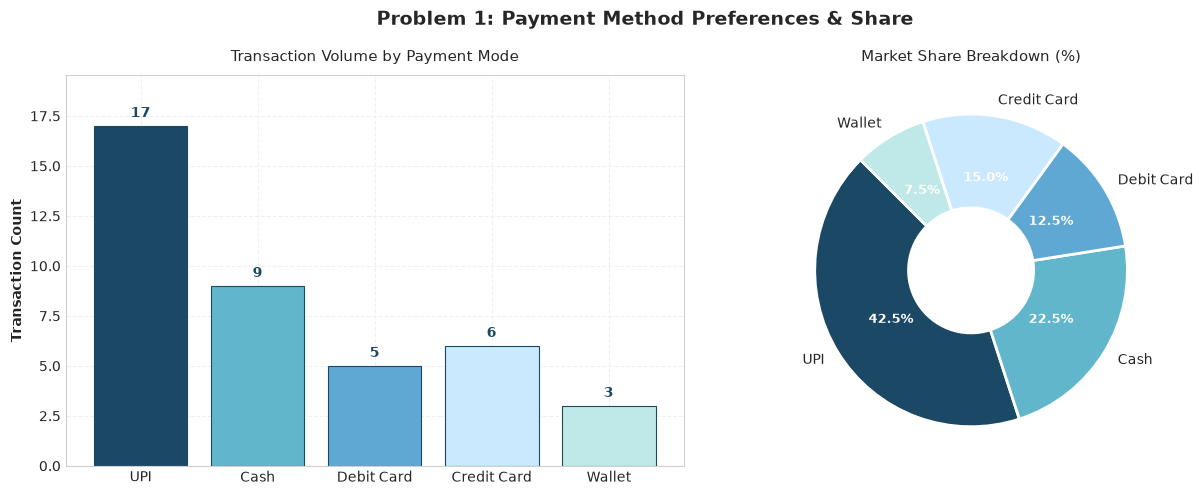

In [7]:
# Load sheet and clean header whitespace
p1_raw = pd.read_excel(DATA_PATH, sheet_name="P1 Payments")
p1_raw.columns = p1_raw.columns.str.strip()

# Clean frequency table dynamically
p1_df = p1_raw[["Mode", "Frequnecy", "Percent"]].dropna()
p1_df = p1_df[p1_df["Mode"].astype(str).str.strip().str.upper() != "TOTAL"]

# Custom Oceanic Hex Palette
ocean_palette = ["#1B4965", "#62B6CB", "#5FA8D3", "#CAE9FF", "#BEE9E8"]

fig, (ax_bar, ax_donut) = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(
    "Problem 1: Payment Method Preferences & Share",
    fontsize=14,
    fontweight="bold",
)

# 1. Bar Chart (Frequency Count)
bars = ax_bar.bar(
    p1_df["Mode"],
    p1_df["Frequnecy"],
    color=ocean_palette,
    edgecolor="#1B4965",
    linewidth=0.8,
)
ax_bar.set_title("Transaction Volume by Payment Mode", fontsize=11, pad=10)
ax_bar.set_ylabel("Transaction Count", fontweight="bold")
ax_bar.set_ylim(0, max(p1_df["Frequnecy"]) * 1.15)

for bar in bars:
    h = bar.get_height()
    ax_bar.annotate(
        f"{int(h)}",
        xy=(bar.get_x() + bar.get_width() / 2, h),
        xytext=(0, 4),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontweight="bold",
        color="#1B4965",
    )

# 2. Donut Chart (Proportional Share)
wedges, texts, autotexts = ax_donut.pie(
    p1_df["Percent"],
    labels=p1_df["Mode"],
    autopct="%1.1f%%",
    startangle=135,
    colors=ocean_palette,
    wedgeprops={"edgecolor": "white", "linewidth": 2, "width": 0.6},
)
plt.setp(autotexts, size=9.5, weight="bold", color="white")
ax_donut.set_title("Market Share Breakdown (%)", fontsize=11, pad=10)

plt.tight_layout()
plt.show()

## 3. Problem 2: Delivery Time Frequency & Cumulative Ogive Chart
**Objective:** Evaluate order delivery performance across designated time windows.  
**Approach:** 
- Extract frequency distribution data from sheet `P2 Delivery`.
- Construct a **Dual-Axis Combination Chart** featuring a semi-translucent primary bar chart for class frequencies and an overlay **Ogive Line** displaying cumulative percentages across time thresholds.

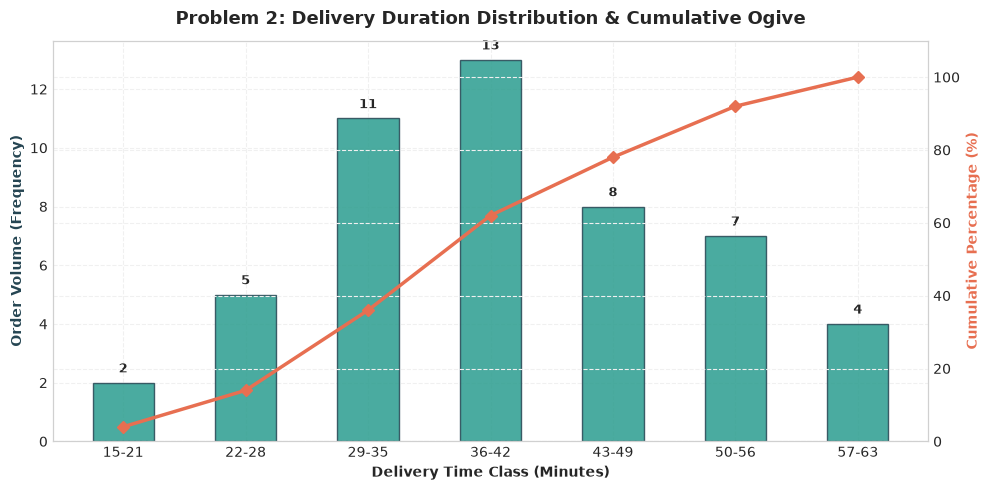

In [8]:
p2_raw = pd.read_excel(DATA_PATH, sheet_name="P2 Delivery")
p2_raw.columns = p2_raw.columns.str.strip()
p2_df = p2_raw[["Class", "Frequency", "Cum. Percent"]].dropna()

fig, ax_hist = plt.subplots(figsize=(10, 5))
ax_ogive = ax_hist.twinx()

# Primary Axis: Frequency Bars
rects = ax_hist.bar(
    p2_df["Class"],
    p2_df["Frequency"],
    color="#2A9D8F",
    alpha=0.85,
    width=0.5,
    edgecolor="#264653",
)

# Secondary Axis: Cumulative Percent Ogive
ax_ogive.plot(
    p2_df["Class"],
    p2_df["Cum. Percent"],
    color="#E76F51",
    marker="D",
    linewidth=2.5,
    markersize=6,
    label="Cumulative Share",
)

ax_hist.set_title(
    "Problem 2: Delivery Duration Distribution & Cumulative Ogive",
    fontsize=13,
    fontweight="bold",
    pad=12,
)
ax_hist.set_xlabel("Delivery Time Class (Minutes)", fontweight="bold")
ax_hist.set_ylabel(
    "Order Volume (Frequency)", color="#264653", fontweight="bold"
)
ax_ogive.set_ylabel(
    "Cumulative Percentage (%)", color="#E76F51", fontweight="bold"
)
ax_ogive.set_ylim(0, 110)

for rect in rects:
    val = rect.get_height()
    ax_hist.text(
        rect.get_x() + rect.get_width() / 2,
        val + 0.25,
        int(val),
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold",
    )

plt.tight_layout()
plt.show()

## 4. Problem 3: Laptop Sales Analysis (Brand vs. Price Band)
**Objective:** Examine brand concentration and pricing tier segmentations.  
**Approach:** 
- Perform dynamic cross-tabulation using `pandas.crosstab()` on sheet `P3 Laptops`.
- Display a **Stacked Bar Chart** for price tier compositions alongside an **Annotated Heatmap Matrix** to visualize transaction densities per brand-price intersection.

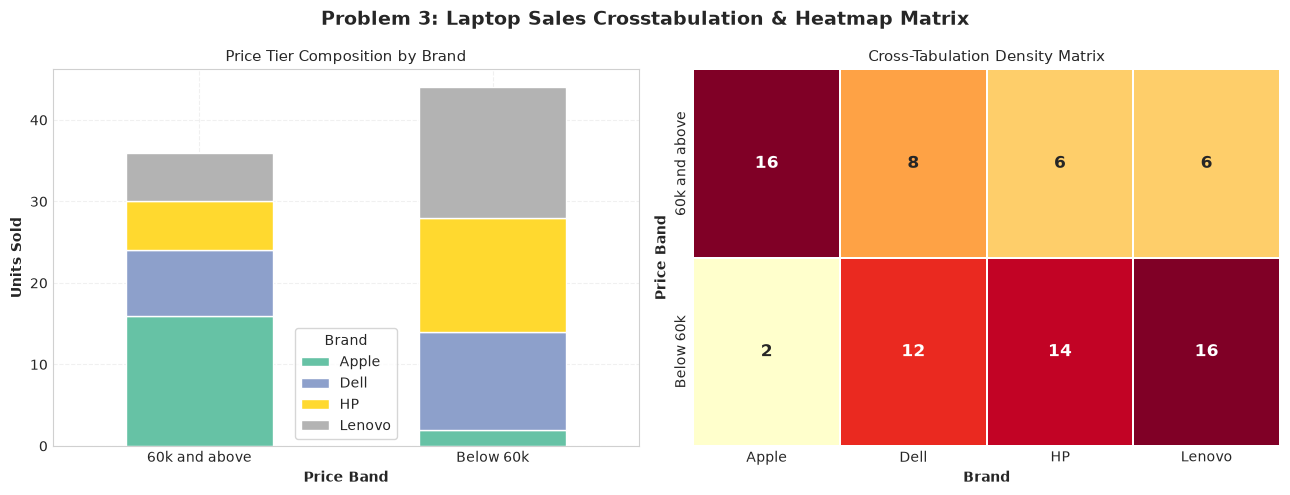

In [9]:
p3_raw = pd.read_excel(DATA_PATH, sheet_name="P3 Laptops")
p3_raw.columns = p3_raw.columns.str.strip()

# Build Cross-Tabulation Matrix
laptop_matrix = pd.crosstab(p3_raw["Price band"], p3_raw["Brand"])

fig, (ax_stack, ax_map) = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(
    "Problem 3: Laptop Sales Crosstabulation & Heatmap Matrix",
    fontsize=14,
    fontweight="bold",
)

# 1. Stacked Composition Bar Plot
laptop_matrix.plot(
    kind="bar", stacked=True, ax=ax_stack, colormap="Set2", edgecolor="white"
)
ax_stack.set_title("Price Tier Composition by Brand", fontsize=11)
ax_stack.set_ylabel("Units Sold", fontweight="bold")
ax_stack.set_xlabel("Price Band", fontweight="bold")
ax_stack.tick_params(axis="x", rotation=0)
ax_stack.legend(title="Brand", frameon=True)

# 2. Annotated Matrix Heatmap
sns.heatmap(
    laptop_matrix,
    annot=True,
    fmt="d",
    cmap="YlOrRd",
    cbar=False,
    linewidths=1.2,
    ax=ax_map,
    annot_kws={"size": 12, "weight": "bold"},
)
ax_map.set_title("Cross-Tabulation Density Matrix", fontsize=11)
ax_map.set_xlabel("Brand", fontweight="bold")
ax_map.set_ylabel("Price Band", fontweight="bold")

plt.tight_layout()
plt.show()

## 5. Problem 4: Advertising Expenditure vs. Sales Revenue
**Objective:** Assess the relationship and trend between monthly advertising expenditure and sales.  
**Approach:** 
- Clean continuous variables from sheet `P4 Ads`.
- Plot a **Scatter Regression Plot** using `sns.regplot()` featuring a dashed trendline and explicit point-level annotations for monthly tracking.

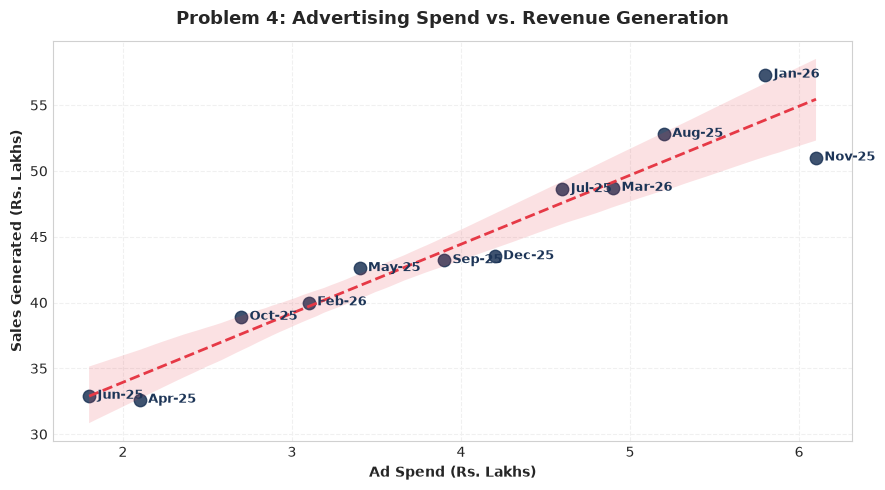

In [10]:
p4_raw = pd.read_excel(DATA_PATH, sheet_name="P4 Ads")
p4_raw.columns = p4_raw.columns.str.strip()
p4_df = p4_raw[
    ["Month", "Ad spend (Rs lakh)", "Sales (Rs lakh)"]
].dropna()

fig, ax_reg = plt.subplots(figsize=(9, 5))

# Regression plot with scatter points and trendline
sns.regplot(
    data=p4_df,
    x="Ad spend (Rs lakh)",
    y="Sales (Rs lakh)",
    ax=ax_reg,
    color="#457B9D",
    scatter_kws={"s": 80, "alpha": 0.85, "color": "#1D3557"},
    line_kws={"color": "#E63946", "linewidth": 2, "linestyle": "--"},
)

# Annotate each data point with month name
for _, row in p4_df.iterrows():
    ax_reg.annotate(
        row["Month"],
        (row["Ad spend (Rs lakh)"], row["Sales (Rs lakh)"]),
        xytext=(6, -2),
        textcoords="offset points",
        fontsize=9,
        color="#1D3557",
        fontweight="bold",
    )

ax_reg.set_title(
    "Problem 4: Advertising Spend vs. Revenue Generation",
    fontsize=13,
    fontweight="bold",
    pad=12,
)
ax_reg.set_xlabel("Ad Spend (Rs. Lakhs)", fontweight="bold")
ax_reg.set_ylabel("Sales Generated (Rs. Lakhs)", fontweight="bold")

plt.tight_layout()
plt.show()